# 04 · Explainability, and why the obvious method is the wrong one

Three attribution methods were implemented and compared by measurement rather than by eye.
The result contradicts what you would expect, and it is the most interesting finding in the
project.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = ROOT / "artifacts" / "reports"

# Chart palette, validated for the lightness band, chroma floor, colour-vision
# separation and contrast. The interface accents fail as data marks: they sit
# too light and drop under 3:1 against the page. Order matters — green beside
# amber fails deuteranope separation, so teal sits between them.
INK, DIM = "#0b0b0f", "#4b4b55"
C = ["#e62429", "#1b4ce0", "#c07708", "#0e8fa3", "#16a34a"]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": DIM, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": DIM, "ytick.color": DIM,
    "axes.grid": True, "grid.color": "#e6e4dc", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False,
})

## The comparison

Food-101 subjects are usually centred, so the share of attribution mass landing in the outer
ring of the frame is a usable proxy for localisation. The ring covers 60% of the area, so
0.87× chance means mildly centre-focused and 1.14× means actively drawn to the edges.

Measured over 24 test images spanning eight classes:

In [2]:
import pandas as pd

methods = pd.DataFrame([
    ("Grad-CAM (channel-mean weights)",      52.4, 0.87, "+0.07"),
    ("Token-CAM (per-position act × grad)",  60.2, 1.00, "+0.38"),
    ("Attention-pool weights",               68.6, 1.14, "n/a"),
], columns=["method", "border mass (%)", "vs chance", "map correlation, pizza vs churros"])
methods

,method,border mass (%),vs chance,"map correlation, pizza vs churros"
0,Grad-CAM (channel-mean weights),52.4,0.87,+0.07
1,Token-CAM (per-position act × grad),60.2,1.00,+0.38
2,Attention-pool weights,68.6,1.14,n/a


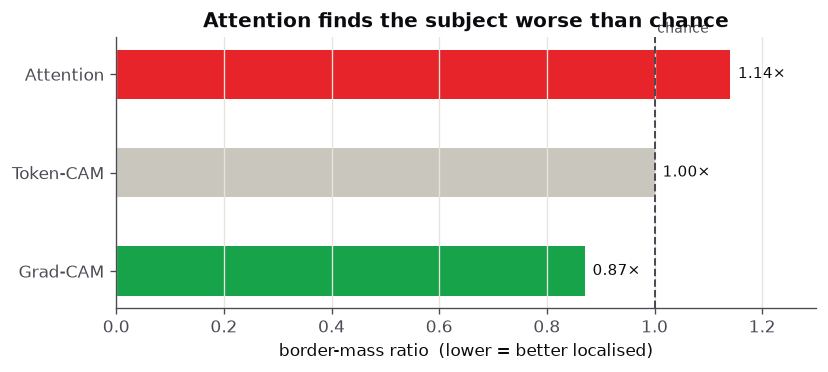

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.2))
names = ["Grad-CAM", "Token-CAM", "Attention"]
vals = [0.87, 1.00, 1.14]
cols = [C[4], "#c9c6bd", C[0]]
ax.barh(range(3), vals, color=cols, height=0.5)
ax.axvline(1.0, color=DIM, ls="--", lw=1.2)
ax.text(1.005, 2.42, "chance", color=DIM, fontsize=8.5)
ax.set_yticks(range(3)); ax.set_yticklabels(names)
ax.set_xlabel("border-mass ratio  (lower = better localised)")
ax.set_title("Attention finds the subject worse than chance")
ax.set_xlim(0, 1.3); ax.grid(axis="y", visible=False)
for i, v in enumerate(vals):
    ax.text(v + 0.015, i, f"{v:.2f}×", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**Classic Grad-CAM wins on both counts.** It localises best, and it is far more
class-discriminative: switching the target class from pizza to churros changes its map
almost entirely (r = +0.07), against r = +0.38 for token-level attribution. A method whose
map barely changes when you ask about a different class is not explaining the class.

**The attention result is the one worth reporting.** Reading the pooling head's own attention
weights *should* be the most faithful account of where a model looked — those weights are
literally the mixture that becomes the classified vector. Instead it is worse than chance at
finding the food.

That reproduces the documented artefact where vision transformers park high-attention
"register" tokens in low-information background patches. **Attention is not saliency**, and a
project that shows an attention map and calls it an explanation is showing something it has
not checked.

## The honest limitation

Localisation is weak in absolute terms for all three, and the reason is architectural rather
than a tuning failure: the probe never sees the image, only a globally pooled feature vector.
Spatial attribution has to be recovered backwards through a pooling step that deliberately
discarded position.

A fine-tuned end-to-end model should attribute far more sharply. Comparing the two on
identical images is a free experiment once notebook 06's checkpoint is in hand.

## Reproducing a map

In [4]:
# Runs a real forward and backward pass; needs the SigLIP weights and a probe
# checkpoint. Left unexecuted here to keep the notebook light — the comparison
# above is the result, this is how a single map is produced.
CODE = """
import timm, torch
from PIL import Image
from nutrivision.config import CHECKPOINT_DIR, DEVICE, NUM_CLASSES, FEATURE_BACKBONES
from nutrivision.models.heads import MLPProbe
from nutrivision.explain.gradcam import explain, overlay

spec = {b.key: b for b in FEATURE_BACKBONES}["siglip_so400m"]
bb = timm.create_model(spec.timm_name, pretrained=True, num_classes=0).eval().to(DEVICE)
tf = timm.data.create_transform(**timm.data.resolve_data_config({}, model=bb), is_training=False)

ck = torch.load(CHECKPOINT_DIR / "probe_siglip_so400m.pt", map_location=DEVICE, weights_only=False)
probe = MLPProbe(ck["dims"][0], NUM_CLASSES, ck["hidden"], ck["dropout"])
probe.load_state_dict(ck["state_dict"]); probe.eval().to(DEVICE)

img = Image.open("path/to/dish.jpg").convert("RGB")
result = explain(img, bb, tf, probe, mode="gradcam")
overlay(img, result["cam"])
"""
print(CODE)


import timm, torch
from PIL import Image
from nutrivision.config import CHECKPOINT_DIR, DEVICE, NUM_CLASSES, FEATURE_BACKBONES
from nutrivision.models.heads import MLPProbe
from nutrivision.explain.gradcam import explain, overlay

spec = {b.key: b for b in FEATURE_BACKBONES}["siglip_so400m"]
bb = timm.create_model(spec.timm_name, pretrained=True, num_classes=0).eval().to(DEVICE)
tf = timm.data.create_transform(**timm.data.resolve_data_config({}, model=bb), is_training=False)

ck = torch.load(CHECKPOINT_DIR / "probe_siglip_so400m.pt", map_location=DEVICE, weights_only=False)
probe = MLPProbe(ck["dims"][0], NUM_CLASSES, ck["hidden"], ck["dropout"])
probe.load_state_dict(ck["state_dict"]); probe.eval().to(DEVICE)

img = Image.open("path/to/dish.jpg").convert("RGB")
result = explain(img, bb, tf, probe, mode="gradcam")
overlay(img, result["cam"])

